## Computer Vision
**What is Computer Vision?**

Computer Vision (CV) is the field of AI that lets machines **interpret and understand visual information** like images and videos.

**Applications:**
- Medical imaging: tumor detection, X-ray analysis
- Self-driving cars: lane detection, obstacle avoidance  
- Face recognition and authentication
- Google Lens, reverse image search
- Surveillance systems
- Quality control in manufacturing
- Image classification

### **Core Techniques**
1. Image Processing: 
    - Techniques for manipulating and enhancing digital images, including noise reduction, image transformations, and morphological operations 

2. Feature Extraction: 
    - Identifying distinctive elements in an image, such as **edges**, **corners**, and **textures**, which are crucial for analysis 

3. Deep Learning Models: 
    - Modern computer vision relies heavily on neural networks:
    
    1. **Convolutional Neural Networks (CNNs)**: Learn spatial hierarchies of features for tasks like image classification and object detection 
    
    2. Vision Transformers (ViT): Process images as sequences of patches using self-attention, often outperforming CNNs in certain tasks 
    
    3. Generative Models (GANs, VAEs): Generate realistic images or learn latent representations for complex visual tasks 
    
    4. Vision-Language Models: Integrate visual and textual information for tasks like image captioning and multimodal understanding 

### **Key Tasks**

1. **Image Classification**: Assigning a label to an image based on its content 

2. Object Detection: Identifying and locating objects within an image using bounding boxes 

3. Image Segmentation: Partitioning an image into regions to identify objects or boundaries at the pixel level 

4. Pose Estimation and OCR: Determining human body orientation or converting text in images into machine-readable formats

## **Convolutional Neural Networks**, 
- or CNNs, are a specialized class of neural networks designed to effectively process grid-like data
    - such as images
- Uses an operation called **Convolution** to process grid like data (images)
- They preserve spatial relationships 
- And learn from hierarchical features: Edge -> Shape -> Object
- 

[Introduction to Convolutional Neural Networks in Deep Learning](https://www.analyticsvidhya.com/blog/2022/03/basic-introduction-to-convolutional-neural-network-in-deep-learning)

![](https://editor.analyticsvidhya.com/uploads/94787Convolutional-Neural-Network.jpeg)

It is made up of multiple layers, including convolutional layers, pooling layers, and fully connected layers to automatically detect spatial hierarchies in the data (e.g., edges, textures, and patterns).

![](https://miro.medium.com/freeze/max/661/1*sCUNjAOQvXc3dr8dcSSfoA.gif)

- **Convolutional Layers**
    - These layers apply convolutional operations to input images, using filters (also known as kernels) of a specific size *M x M*
    - Detect features such as edges, textures, and more complex patterns 
    - Convolutional operations help preserve the spatial relationships between pixels 


- **Pooling Layers**
    - These layers downsample the spatial dimensions of the input, reducing the computational complexity and the number of parameters in the network
    - **Max Pooling** is a common pooling operation, **selecting the maximum value** from a group of neighboring pixels
    - **Average Pooling** calculates the total sum of components in a predefined section

- **Dropout**
    - To avoid overfitting, this layer removes a few neurons from the neural network during training
    - results in a smaller model


Some of the layers in a CNN:
- Conv2D:
    - It applies learnable filters (kernels) to an input image (or feature map) to extract spatial features such as edges, textures, and patterns
    ![](https://media.geeksforgeeks.org/wp-content/uploads/20230216175224/how-to-apply-a-2d-convolution-operation-in-pytorch.gif)
    - [Conv2D](https://www.geeksforgeeks.org/computer-vision/apply-a-2d-convolution-operation-in-pytorch/)

- MaxPool2D:
    - MaxPool2D is a pooling operation used in convolutional neural networks (CNNs) to downsample spatial dimensions (height and width) of feature maps while retaining the most important features. 
    ![](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*gaD6SJ6kQNVOclE_WkwLNQ.png)
    - 

- Let's build something and learn along the way
- **Handwritten Digit Recognition System**

In [7]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

In [9]:
# get the data
data = tf.keras.datasets.mnist.load_data()
type(data)
len(data[0])

(X_train, y_train), (X_test, y_test) = data

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  13  25 100
  122   7   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  33 151 208 252 252
  252 146   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  40 152 244 252 253 224 211
  252 232  40   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  15 152 239 252 252 252 21

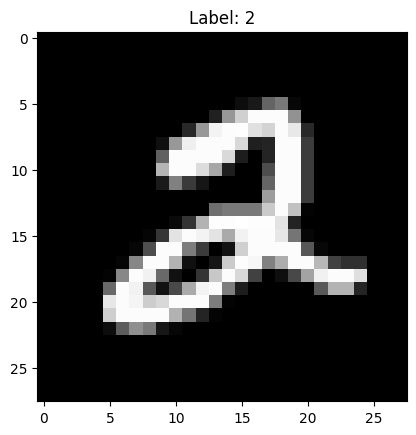

In [10]:
data[0] # shape=(60000, 28, 28) --- Training set (X_train, y_train)
data[1] # shape=(10000, 28, 28) --- Testing set (X_test, y_test)

len(data[0][0]) # 60000 --- Images - every one is 28 x 28 --- X_train
len(data[0][1]) # 60000 --- Labels - you have a digit as well --- y_train
# 60K images, 2D images

# np.set_printoptions(linewidth=150)
print(data[0][0][5]) # zeroth image

plt.imshow(X_train[5], cmap = 'grey')
plt.title(f"Label: {y_train[5]}")
plt.show()

In [11]:
X_train[5].shape
len(X_train[0].flatten())

# np.unique(y_train)

784

- images are just numbers stored in arrays
- 2D with 1 channel - Gray scale image
- 3D with 3 channels - R G B
- 
- grayscale image matrix ===> (28, 28, 1)
- Color images ===> (28, 28, 3) (height, width, channels)

In [12]:
# Modeling
from tensorflow.keras import layers

DL_model = tf.keras.models.Sequential([
    # input layer
    layers.Flatten(input_shape = (28, 28)), # squishes the 2D array into a 1D array
    layers.Dense(128, activation= 'relu'),
    layers.Dense(10, activation ='softmax') # loudest voice

])

DL_model.compile(optimizer= 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

DL_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train and Evaluate
DL_model.fit(X_train, y_train, epochs = 3, batch_size = 10)

test_loss, test_acc = DL_model.evaluate(X_test, y_test)

Epoch 1/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.8509 - loss: 1.5606
Epoch 2/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.9057 - loss: 0.3942
Epoch 3/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.9186 - loss: 0.3558
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9157 - loss: 0.3747


In [14]:
print(f"Test accuracy of the model is: {test_acc*100:.2f}% ")

Test accuracy of the model is: 91.57% 


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


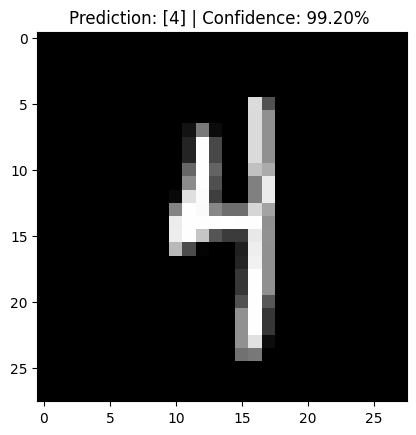

In [15]:
# make an arbitrary prediction

img = X_test[65]

prediction_img = DL_model.predict(img.reshape(1, 28, 28))
                                  
prediction_label = np.argmax(prediction_img, axis = 1)
confidence = prediction_img[0][prediction_label]


plt.imshow(img, cmap= 'gray')
plt.title(f"Prediction: {prediction_label} | Confidence: {float(confidence)*100:.2f}% ")
plt.show()

In [16]:
prediction_img[0][prediction_label]

array([0.9920151], dtype=float32)

In [17]:
img = X_test[10]

img.reshape(1, 28, 28).shape

# np.expand_dims(img, 0).shape

(1, 28, 28)

In [18]:
predictions = DL_model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

report = classification_report(y_pred, y_test)

print(report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       995
           1       0.98      0.98      0.98      1131
           2       0.94      0.88      0.91      1096
           3       0.84      0.98      0.90       868
           4       0.87      0.97      0.91       883
           5       0.92      0.92      0.92       891
           6       0.86      0.99      0.92       829
           7       0.90      0.98      0.94       943
           8       0.93      0.70      0.80      1285
           9       0.93      0.87      0.90      1079

    accuracy                           0.92     10000
   macro avg       0.91      0.92      0.92     10000
weighted avg       0.92      0.92      0.91     10000



#### Let's implement CNN for the same thing
- 

In [19]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dropout, Dense
from tensorflow.keras.models import Sequential


# tensorflow model will take the shape as (height, width, channels) --- multiple channels too
def idrees_cnn(input_shape = (28, 28, 1), num_classes = 10):
    model = Sequential()

    # part 1: Edge and basic shape detection
    model.add(Conv2D(filters = 32, input_shape = input_shape, kernel_size=(3,3), activation= 'relu'))
    model.add(MaxPool2D(pool_size = (2,2)))

    # part 2 ===> detect more features
    model.add(Conv2D(64, kernel_size=(3,3), activation= 'relu'))
    model.add(MaxPool2D(pool_size = (2,2)))
    
    # conversion to 1D === convolution part is done. now we need the training power. brain cells
    model.add(Flatten())

    # we add dropouts, to reduce overfitting
    model.add(Dropout(0.5)) # turns off 50% of the neurons in the network will be turned off randomly

    # add a dense layers --- fully connected --
    model.add(Dense(128, activation= 'relu'))

    # output layer
    model.add(Dense(units = num_classes, activation= 'softmax'))

    model.compile(optimizer= 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model



In [20]:
model = idrees_cnn()

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# data 
data = tf.keras.datasets.mnist.load_data()

# already train test splitted data
(X_train, y_train), (X_test, y_test) = data

X_train.shape

(60000, 28, 28)

In [22]:
# data preprocessing

# why do we change from 2D to 3D -- tensorflow models genrally take this shape for 3D arrays - images
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

# we perform scaling operations as well to improve model performance
# # if you have big values in data --- gradient decent faces issues -- explosive gradients
# X_train = X_train/255
# X_test = X_test/255

In [23]:
# training

history = model.fit(X_train, y_train,
          epochs = 5, 
          batch_size = 10,
          validation_split = 0.2 # you can get the training and testing accuracy
          )

# history can be used to plot the test vs training accuracies over the multiple epochs


Epoch 1/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - accuracy: 0.9105 - loss: 0.4653 - val_accuracy: 0.9768 - val_loss: 0.0713
Epoch 2/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - accuracy: 0.9582 - loss: 0.1400 - val_accuracy: 0.9792 - val_loss: 0.0710
Epoch 3/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - accuracy: 0.9655 - loss: 0.1172 - val_accuracy: 0.9837 - val_loss: 0.0564
Epoch 4/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9710 - loss: 0.0995 - val_accuracy: 0.9754 - val_loss: 0.0824
Epoch 5/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - accuracy: 0.9723 - loss: 0.0988 - val_accuracy: 0.9784 - val_loss: 0.0748


In [24]:
# evaluation
test_loss, test_accuracy = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9765 - loss: 0.0698


In [25]:
# save the model
model.summary()

model.save('idrees_digit_recog_model.keras')

# .keras

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

- Model parameters will define the complexity of the model
- Tensorflow, saved model formats:
    - .keras - recommended for Keras models
        - saves everything, packages the model architecture ---> weights and the optimizer states --> so you can train again from where you left off
    - .h5 - single file model format from older versions of TF and keras.
        - should not use this for new projects, it struggles to save custom code properly
    - SavedModel format - a folder and a file saved_model.pb file

### Test with real inputs
- Let's take that model, and make predictions with it
- 

In [26]:
import numpy as np

from PIL import Image, ImageOps

import tensorflow as tf

In [27]:
# load the model

model = tf.keras.models.load_model('idrees_digit_recog_model.keras')

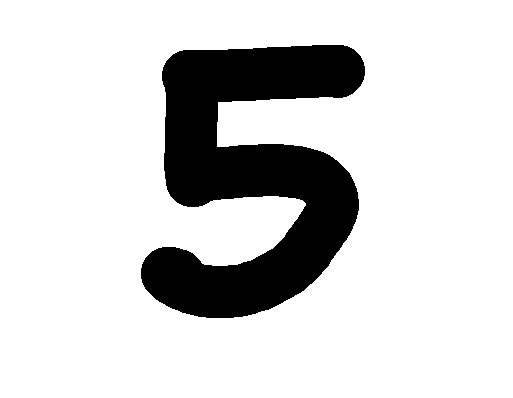

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  54 122 123 133 145 166 178 192 205
  201  81   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  21 229 255 255 255 255 255 255 255 255
  255 213   5   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  44 253 255 255 255 255 255 255 255 255
  255 212   5   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  18 231 255 255 252 247 237 229 220 210
  208  82   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  12 224 255 226  53  36  24  16   9   4
    3   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  18 232 255 213   0   0   0   

(1, 28, 28, 1)

In [28]:
# take the image, and make predictions using the model

path = 'test_2.jpg'

img = Image.open(path)
display(img)

# data preprocessing
img.size
# size is (513, 398)
img = img.resize((28,28))
display(img)

# greyscale the image
img = img.convert('L') # change the 4 channel image into grey scale
display(img)

# will turn white into black
img = ImageOps.invert(img) # ivnerts the image

# convert into a numpy array
img_array = np.array(img)
img_array.shape
print(img_array)

# reshape
img_array = img_array.reshape(1, 28, 28, 1)
img_array.shape


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


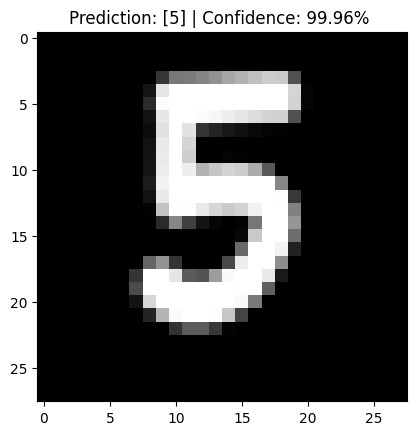

In [29]:
# make prediction

prediction_img = model.predict(img_array)
                                  
prediction_label = np.argmax(prediction_img, axis = 1)
confidence = prediction_img[0][prediction_label]


plt.imshow(img, cmap= 'gray')
plt.title(f"Prediction: {prediction_label} | Confidence: {float(confidence)*100:.2f}% ")
plt.show()

---

In [30]:
# all of this in one function

import tensorflow as tf
import numpy as np
from PIL import Image, ImageOps

# 1. Load your saved model
model = tf.keras.models.load_model('idrees_digit_recog_model.keras')

def predict_custom_image(path):
    # 2. Open image with PIL
    img = Image.open(path)
    
    # 3. Preprocess: Convert to Grayscale ('L' mode)
    img = img.convert('L')
    
    # 4. Resize to 28x28
    img = img.resize((28, 28))
    
    # 5. Invert Colors (Optional)
    # MNIST data is white ink on black background. 
    # If you drew black ink on white paper, you MUST invert it.
    img = ImageOps.invert(img)
    
    # 6. Convert to Numpy Array and Normalize
    img_array = np.array(img)
    # img_array = img_array/ 255.0 # we did not train our model
    
    # 7. Reshape to match (Batch, Width, Height, Channel)
    # Shape becomes (1, 28, 28, 1)
    img_array = img_array.reshape(1, 28, 28, 1)
    
    # 8. Inference
    prediction = model.predict(img_array)

    result = np.argmax(prediction, axis = 1)
    
    confidence = np.max(prediction)
    
    print(f"Prediction: {result} (Confidence: {confidence*100:.2f}%)")

    return result

In [31]:
# Run it!

path = 'test_1.png'

predict_custom_image(path = path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Prediction: [2] (Confidence: 44.70%)


array([2])